In [1]:
! which python

'which' is not recognized as an internal or external command,
operable program or batch file.


# Homework 4
   
 - All questions must be answered in your own words, do not copy-paste text from the internet. Points can be deducted for terrible formatting or incomprehensible English.

 - Code must be commented. If you use code you found online, you have to add the link to the source you used. There is no penalty for using outside sources as long as you convince us you understand the code.

  **To pass the homework you need to attempt to do all tasks. If we see that you misunderstand some concept, you may receive personal feedback and you can have a chance to resubmit your homework.**
 **Please treat these homeworks as learning opportunities to support your study! Instead of copy-pasting solution, attempt to do it yourself and rather learn from feedback**

**You can earn up to 5 bonus points by tuning the hyperparameters and reaching test accuracies above 52%**

*Once completed zip the entire directory containing this exercise and upload it to Moodle.
   
For background reading see http://cs231n.github.io/optimization-2/  
http://vision.stanford.edu/teaching/cs231n/handouts/derivatives.pdf  
https://web.stanford.edu/class/cs224n/readings/gradient-notes.pdf



## Applied Theory

In this exercise we have a neural network with one hidden layer. This time we derive gradients slightly differently:
1. we use batch of samples instead of one sample,
2. **we use matrix calculus for gradients,**
3. we add L2 regularization to the loss.

![alt text][logo]

[logo]: http://cs231n.github.io/assets/nn1/neural_net.jpeg "Logo Title Text 2"


Notation:
 * $\mathbf{X}$ is $N \times D$ input matrix, where $N$ is number of samples in batch and $D$ is number of features.
 * $\mathbf{Y}$ is $N \times C$ one-hot coded target matrix, where $N$ is number of samples in batch and $C$ is number of classes.
 * $\mathbf{c}$ is $N$-dimensional vector of correct classes for all samples, $\mathbf{c}_i \in \{1, \ldots, C\}$.
 * $\mathbf{W}^{(1)}$ is $D \times M$ weight matrix of the first layer, where $D$ is the number of features and $M$ is number of hidden nodes.
 * $\mathbf{W}^{(2)}$ is $M \times C$ weight matrix of the second layer, where $M$ is the number of hidden nodes and $C$ is the number of classes.
 * $\mathbf{b}^{(1)}$ is bias vector of the first layer with dimension of $1 \times M$.
 * $\mathbf{b}^{(2)}$ is bias vector of the second layer with dimension of $1 \times C$.
 * $1_N$ is a column vector of ones of length N with dimension $N \times 1$
 * $\text{ReLU}(x) = \max(x, 0)$ is rectified linear unit activation function.
 * $\mathbf{P} = \text{softmax}(\mathbf{A})$ converts activations into probabilities row by row $\mathbf{P}_{ij} = \frac{e^ {\mathbf{A}_{ij}}}{\sum_k e^{\mathbf{A}_{ik}}}$.



**Feed-forward pass:**
$$
\begin{align*}
\mathbf{A}^{(1)} &= \mathbf{X} \mathbf{W}^{(1)} + 1_N \mathbf{b}^{(1)}   &(N\times M)
\\
\mathbf{H}^{(1)} &= \text{ReLU}(\mathbf{A}^{(1)}) &(N\times M)
\\
\mathbf{A}^{(2)} &= \mathbf{H}^{(1)} \mathbf{W}^{(2)} + 1_N \mathbf{b}^{(2)} &(N\times C)
\\
\mathbf{P} &= \text{softmax}(\mathbf{A}^{(2)}) &(N\times C)
\\
L_{CE} &= -\frac{1}{N} \sum_{i=1}^{N} \mathbf{Y}_{i\cdot} \odot \log \mathbf{P}_{i\cdot} = 
-\frac{1}{N} \sum_{i=1}^{N} \log \mathbf{P}_{i\mathbf{c}_i}   &(\text{scalar})
\end{align*}
$$

Here $AB$ is matrix multiplication and $A\odot B$ is element-wise multiplication.  
$\frac{1}{N}$ in the loss function produces mean instance loss, which is good because then loss value does not depend on batch size. If we had used sum, both loss value and gradients would have different magnitude for different batch sizes and we would need to adapt learning rate for each batch size.

<br><br>
**Backward pass:**  
Derivatives of matrix multiplication work very similarly to the scalar case. However, as the order of elements in product matters (AB $\neq$ BA), pay attention to transposes and also on which side of the overall expression the derviative ends up. Suppose  
  $$ L = f(Y),\qquad Y = XW.$$
Then
\begin{align*}
\frac{\partial L}{\partial X} &=  \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial X}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial X} =\frac{\partial L}{\partial Y} W^T\\
\frac{\partial L}{\partial W} &= \frac{\partial L}{\partial Y} \frac{\partial Y}{\partial W}= \frac{\partial L}{\partial Y} \frac{\partial XW}{\partial W} = X^T  \frac{\partial L}{\partial Y}.
\end{align*}
Notice that the multiplication with transposed matrix is from different sides in these two cases.

Backward pass for $\mathbf{W}^{(1)}$ using chain rule:
\begin{align*}
    \frac{\partial L_{CE}}{\partial\mathbf{W}^{(1)}} &= \frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}}\frac{\partial \mathbf{A}^{(1)}}{\partial\mathbf{W}^{(1)}} & \text{(chain rule)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{A}^{(1)}} & \text{(previous formula)}\\
    &= X^T\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\frac{\partial\mathbf{H}^{(1)}}{\partial\mathbf{A}^{(1)}} & \text{(chain rule)}\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)\\
    &= X^T\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}\frac{\partial\mathbf{A}^{(2)}}{\partial\mathbf{H}^{(1)}}\odot(\mathbf{A}^{(1)}>0)\right)&\text{(chain rule)}\\
    &= X^T\left(\left(\frac{\partial L_{CE}}{\partial\mathbf{A}^{(2)}}(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(previous formula)}\\
    &= \frac{1}{N}X^T\left(\left((P-Y)(\mathbf{W}^{(2)})^T\right)\odot(\mathbf{A}^{(1)}>0)\right)&\text{(from previous practice)}
\end{align*}
Here $(\mathbf{A}^{(1)}>0)$ denotes a matrix whose value at row $i$ and column $j$ is one, if the corresponding value in matrix $\mathbf{A}$ is greater than 0, and 0 otherwise.

Write down the partial derivatives of classification loss function with respect to other weights and biases.

The partial derivatives of classification loss function with respect to other weights and biases adjust the parameters of the artificial neural network.

The resulting shape of the matrices shows the compatibility with the network architecture.

#### **!NB** These partial derivatives will help you to do the tasks below. Verify that the dimensions match!

\begin{align*}
\frac{\partial L_{CE}}{\partial\mathbf{W}^{(2)}} &= . . .
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(1)}} &= . . . 
\\
\frac{\partial L_{CE}}{\partial\mathbf{b}^{(2)}} &= . . .
\end{align*}


## L2 regularization

L2 regularization drives the weights to be small.
$$
L_r = \sum_{ij} (\mathbf{W}^{(1)}_{ij})^2 + \sum_{ij} (\mathbf{W}^{(2)}_{ij})^2
$$

In the final loss the classification loss and regularization loss are added together.
$$
L = L_c + \lambda L_r
$$

The strenght of regularization is determined by regularization coefficient $\lambda$.

The derivatives of the regularization penalty for both layers.

#### **!NB** These partial derivates will help you to do the tasks below. Verify that the dimensions match!

$$
\begin{align*}
\frac{\partial L_r}{\partial\mathbf{W}^{(1)}} &= . . .
\\
\frac{\partial L_r}{\partial\mathbf{W}^{(2)}} &= . . .
\end{align*}
$$

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):

    """ returns relative error """

    x = x.to(torch.float64)
    y = y.to(torch.float64)
    return torch.max(torch.abs(x - y) / (torch.max(torch.tensor(1e-8, dtype=torch.float64), torch.abs(x) + torch.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use the class `TwoLayerNet` in the file `neural_net.py` to represent instances of our network. The network parameters are stored in the instance variable `self.params` where keys are string parameter names and values are torch tensors. Below, we initialize toy data and a toy model that we will use to develop your implementation.

In [3]:
# Create a small net and some toy data to check your implementations.
# Note that we set the random seed for repeatable experiments.

def init_toy_model(input_size, hidden_size, num_classes, std):
    """
    Initialize the model. 
    Weights are initialized to small random values and biases are initialized to zero.
    """
    net = TwoLayerNet(input_size, hidden_size, num_classes, std)
    return net

def init_toy_data(num_samples, input_size):

    X = 10 * torch.randn(num_samples, input_size, dtype=torch.float64)
    y = torch.tensor([0, 1, 2, 2, 1], dtype=torch.long)
    
    return X, y


input_size = 4
hidden_size = 10
num_classes = 3
num_samples = 5
std = 1e-1

torch.manual_seed(0)
net = init_toy_model(input_size, hidden_size, num_classes, std)
X, y = init_toy_data(num_samples, input_size)

print('')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


X shape: torch.Size([5, 4])
y shape: torch.Size([5])


# Forward pass: compute scores

### Task 4.1
Open the file `neural_net.py` and look at the method `TwoLayerNet.loss`. This function is very similar to the loss functions you have written for the Softmax exercise: It takes the data and weights and computes the class scores, the loss, and the gradients on the parameters. 

Implement the first part of the forward pass which uses the weights and biases to compute the scores (activations in last layer, before softmax) for all inputs.

In [9]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = torch.tensor([
        [ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)
print(correct_scores)
print()

# The difference should be very small. We get ~ 1e-4
print('Difference between your scores and correct scores:')
score_difference = torch.sum(torch.abs(scores - correct_scores)).item()
print(score_difference)
assert score_difference < 1e-3, f'Task 4.1 failed: score difference too large ({score_difference:.6e})'
print(f'Task 4.1 passed: score difference is small ({score_difference:.6e}).')


Your scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

correct scores:
tensor([[ 0.1169, -0.1993,  0.1278],
        [ 0.1128,  0.4127,  0.1714],
        [ 0.1693,  0.4467, -0.0492],
        [ 0.6434,  0.6163, -0.3690],
        [ 0.0468,  0.3340, -0.0058]], dtype=torch.float64)

Difference between your scores and correct scores:
0.0003600609837727392
Task 4.1 passed: score difference is small (3.600610e-04).


# Forward pass: compute loss
### Task 4.2
In the same function, implement the second part that computes the Cross Entropy loss and regularizaion loss.

In [10]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.2413

# should be very small, we get < 1e-4
print('Difference between your loss and correct loss:')
difference = torch.abs(loss - correct_loss).item()
print(difference)
assert difference < 1e-4, f'Task 4.2 failed: loss difference too large ({difference:.6e})'
print(f'Task 4.2 passed: loss difference is small ({difference:.6e}).')


Difference between your loss and correct loss:
2.1579775491664677e-05
Task 4.2 passed: loss difference is small (2.157978e-05).


# Backward pass
### Task 4.3
Implement the rest of the function. This will compute the gradient of the loss with respect to the variables `W1`, `b1`, `W2`, and `b2`. Now that you (hopefully!) have a correctly implemented forward pass, you can debug your backward pass using a numeric gradient check:

In [19]:
from gradient_check import eval_numerical_gradient

# Use numeric gradient checking to check your implementation of the backward pass.
# If your implementation is correct, the difference between the numeric and
# analytic gradients should be less than 1e-8 for each of W1, W2, b1, and b2.

loss, grads = net.loss(X, y, reg=0.05)

grad_threshold = 1e-8

# these should all be less than 1e-8 or so
for param_name in sorted(grads):
    def f(w):
        old_val = net.params[param_name]
        net.params[param_name] = w
        l, _ = net.loss(X, y, reg=0.05)
        net.params[param_name] = old_val

        return l

    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)

    error = rel_error(param_grad_num, grads[param_name]).item()
    print('%s max relative error: %e' % (param_name, error))
    assert error < grad_threshold, (
        f'Task 4.3 failed for {param_name}: gradient error too large '
        f'({error:.6e} >= {grad_threshold:.1e})'
    )
    print(f'Task 4.3 passed for {param_name}: gradient difference is small ({error:.6e}).')


W1 max relative error: 3.329200e-10
Task 4.3 passed for W1: gradient difference is small (3.329200e-10).
W2 max relative error: 3.915895e-10
Task 4.3 passed for W2: gradient difference is small (3.915895e-10).
b1 max relative error: 9.948489e-09
Task 4.3 passed for b1: gradient difference is small (9.948489e-09).
b2 max relative error: 1.311473e-10
Task 4.3 passed for b2: gradient difference is small (1.311473e-10).


# Train the network
### Task 4.4
To train the network we will use stochastic gradient descent (SGD), similar to the Softmax classifier. Look at the function `TwoLayerNet.train` and fill in the missing sections to implement the training procedure. This should be very similar to the training procedure you used for the Softmax classifier. You will also have to implement `TwoLayerNet.predict`, as the training process periodically performs prediction to keep track of accuracy over time while the network trains.

Once you have implemented the method, run the code below to train a two-layer network on toy data. You should achieve a training loss less than 0.2.

Final training loss:  0.03794584996138343
Task 4.4 passed: final training loss is small (0.037946).


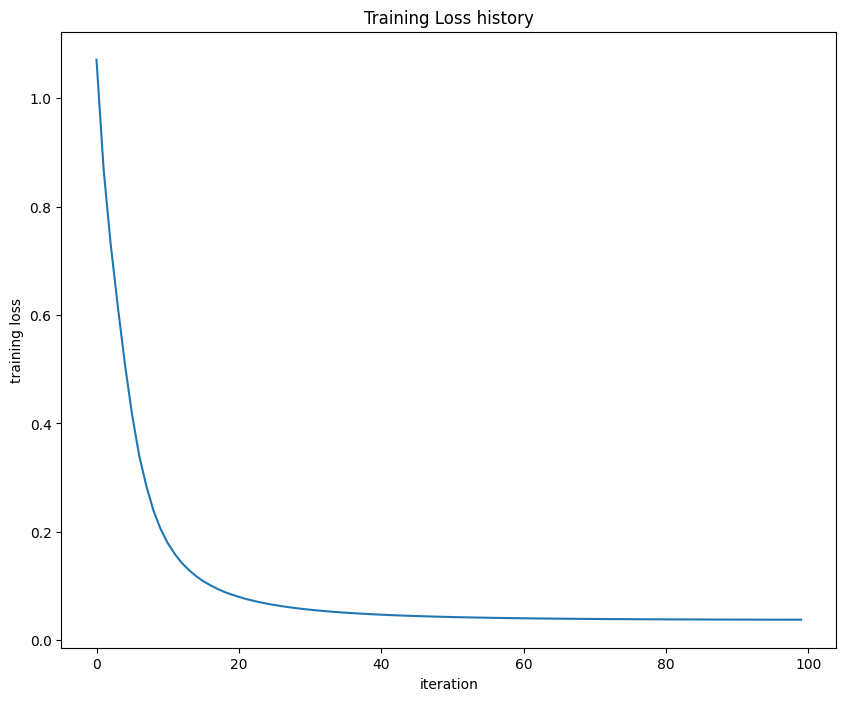

In [20]:
net = init_toy_model(input_size, hidden_size, num_classes, std)
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

final_train_loss = stats['loss_history'][-1]
print('Final training loss: ', final_train_loss)
assert final_train_loss < 0.2, (
    f'Task 4.4 failed: final training loss too high ({final_train_loss:.6f} >= 0.2)'
)
print(f'Task 4.4 passed: final training loss is small ({final_train_loss:.6f}).')

# plot the loss history
plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()


# Load the data
Now that you have implemented a two-layer network that passes gradient checks and works on toy data, it's time to load up our favorite CIFAR-10 data so we can use it to train a classifier on a real dataset.

In [ ]:
from data_utils import load_CIFAR10

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):

    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the two-layer neural net classifier. These are the same steps as
    we used for the SVM, but condensed to a single function.  
    """

    # Load the raw CIFAR-10 data
    cifar10_dir = 'datasets/cifar-10-batches-py/'
    X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar10_dir)
        
    # convert to Torch Tensors
    X_train_raw = torch.from_numpy(X_train_raw).float()
    y_train_raw = torch.from_numpy(y_train_raw).long()
    X_test_raw = torch.from_numpy(X_test_raw).float()
    y_test_raw = torch.from_numpy(y_test_raw).long()

    # Subsample the data
    mask_val = slice(num_training, num_training + num_validation)
    X_val = X_train_raw[mask_val]
    y_val = y_train_raw[mask_val]
    
    # Training
    mask_train = slice(0, num_training)
    X_train = X_train_raw[mask_train]
    y_train = y_train_raw[mask_train]
    
    # Test
    mask_test = slice(0, num_test)
    X_test = X_test_raw[mask_test]
    y_test = y_test_raw[mask_test]

    # Normalize the data: subtract the mean image
    mean_image = torch.mean(X_train, dim=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # Reshape data to rows
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test

# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

X_train = X_train.double()
X_val = X_val.double()
X_test = X_test.double()

print(f'Train data shape: {X_train.shape}')
print(f'Train labels shape: {y_train.shape}')
print(f'Validation data shape: {X_val.shape}')
print(f'Validation labels shape: {y_val.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '../cifar-10-batches-py/data_batch_1'

# Train a network
To train our network we will use SGD. In addition, we will adjust the learning rate with an exponential learning rate schedule as optimization proceeds; after each epoch, we will reduce the learning rate by multiplying it by a number smaller than one called "decay rate".

In [ ]:
input_size = 32 * 32 * 3  
hidden_size = 50
num_classes = 10
std = 1e-3

net = init_toy_model(input_size, hidden_size, num_classes, std)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

# Predict on the validation set
val_predictions = net.predict(X_val)
val_acc = torch.mean((val_predictions == y_val).float()).item()
print('Validation accuracy: ', val_acc)

# Debug the training
With the default parameters we provided above, you should get a validation accuracy of about 0.29 on the validation set. This isn't very good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

In [ ]:
# Plot the loss function and train / validation accuracies
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Clasification accuracy')
plt.legend()
plt.show()

In [ ]:
from vis_utils import visualize_grid

def show_net_weights(net):

    W1 = net.params['W1'].detach().cpu().numpy()
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    
    grid = visualize_grid(W1, padding=3).astype('uint8')
    plt.imshow(grid)
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

# Tune your hyperparameters

**What's wrong?**. Looking at the visualizations above, we see that the loss is decreasing more or less linearly, which seems to suggest that the learning rate may be too low. Moreover, there is no gap between the training and validation accuracy, suggesting that the model we used has low capacity, and that we should increase its size. On the other hand, with a very large model we would expect to see more overfitting, which would manifest itself as a very large gap between the training and validation accuracy.

**Tuning**. Tuning the hyperparameters and developing intuition for how they affect the final performance is a large part of using Neural Networks, so we want you to get a lot of practice. Below, you should experiment with different values of the various hyperparameters, including hidden layer size, learning rate, numer of training epochs, and regularization strength. You might also consider tuning the learning rate decay, but you should be able to get good performance using the default value.

**Approximate results**. You should be aim to achieve a classification accuracy of greater than 48% on the validation set. Our best network gets over 52% on the validation set.

### Task 4.5
**Experiment**: You goal in this exercise is to get as good of a result on CIFAR-10 as you can, with a fully-connected Neural Network. For every 1% above 52% on the Test set we will award you with one extra bonus point. Feel free implement your own techniques (e.g. PCA to reduce dimensionality, or adding dropout, or adding features to the solver, etc.).

In [ ]:
best_net = None # store the best model into this 

#################################################################################
# Task 4.5                                                                      #
# TODO: Tune hyperparameters using the validation set. Store your best trained  #
# model in best_net.                                                            #
#                                                                               #
# To help debug your network, it may help to use visualizations similar to the  #
# ones we used above; these visualizations will have significant qualitative    #
# differences from the ones we saw above for the poorly tuned network.          #
#                                                                               #
# Tweaking hyperparameters by hand can be fun, but you might find it useful to  #
# write code to sweep through possible combinations of hyperparameters          #
# automatically like we did on the previous exercises.                          #
#################################################################################

input_size = 32 * 32 * 3
num_classes = 10
std = 1e-4

learning_rates = []
regularization_strengths = [] 
hidden_sizes = [] 
batch_sizes = [] 

best_val = -1

for lr in learning_rates:
    for reg in regularization_strengths:
        for hidden_size in hidden_sizes:
            for batch_size in batch_sizes:

                # Initialize a new network for each set of hyperparameters
                net = init_toy_model()

                # Train the network

                # Predict on the validation set

                print(f'lr: {lr:.1e}, reg: {reg:.2f}, hidden: {hidden_size}, batch: {batch_size}, val_acc: {val_acc:.4f}')

#################################################################################
#                               END OF YOUR CODE                                #
#################################################################################

hyperparam_lists = [learning_rates, regularization_strengths, hidden_sizes, batch_sizes]
assert all(len(lst) > 0 for lst in hyperparam_lists), (
    'Task 4.5 failed: all hyperparameter lists must be non-empty.'
)
assert any(len(lst) > 1 for lst in hyperparam_lists), (
    'Task 4.5 failed: at least one hyperparameter list must contain more than one value.'
)
print('Task 4.5 setup passed: hyperparameter lists are non-empty and include a sweep dimension.')
assert best_net is not None, 'Task 4.5 failed: best_net was not set.'
print(f'Task 4.5 passed: best model selected with validation accuracy {best_val:.4f}.')

### Task 4.6
Describe how different hyperparameters seem to affect the result and what might be their interactions. Which are the most important and which are less important? Be thorough and mention all hyperparameters you tried. Describe what you see, not general case from textbook.

**Your answer:** 

In [ ]:
# visualize the weights of the best network
show_net_weights(best_net)

# Run on the test set
When you are done experimenting, you should evaluate your final trained network on the test set; you should get above 48%.

### Bonus Task (up to 5 pts):
**We will give you extra bonus point for every 1% of accuracy above 52%. (up to a maximum 5 bonus points)**

In [ ]:
test_acc = (best_net.predict(X_test) == y_test).to(torch.float64).mean().item()
print('Test accuracy: ', test_acc)
assert test_acc > 0.48, f'Test-set requirement failed: accuracy too low ({test_acc:.4f} <= 0.48)'
print(f'Test-set check passed: accuracy is above 48% ({test_acc:.4f}).')

above_52_pct_points = max(0.0, (test_acc - 0.52) * 100.0)
bonus_points = min(5.0, above_52_pct_points)
print(f'Above 52% by: {above_52_pct_points:.2f} percentage points.')
print(f'Bonus points (capped at 5): {bonus_points:.2f}')
